In [18]:
# importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [19]:
# loading dataset
df = pd.read_csv("StudentsPerformance.csv")

In [20]:
# checking first few rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [21]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
df.describe()

Shape of dataset: (1000, 8)

Columns:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Summary Statistics:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [22]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [23]:
# fill categorical missing values with mode
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# fill numeric missing values with median
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

# verify again
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [24]:
# creating average score column
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

# checking
df[['math score', 'reading score', 'writing score', 'average_score']].head()

,math score,reading score,writing score,average_score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


In [25]:
# creating pass/fail result column
df['Result'] = df['average_score'].apply(lambda x: 1 if x >= 50 else 0)

# checking pass/fail count
df['Result'].value_counts()

Result
1    897
0    103
Name: count, dtype: int64

In [26]:
print("Average Math Score:", df['math score'].mean())
print("Average Reading Score:", df['reading score'].mean())
print("Average Writing Score:", df['writing score'].mean())
print("Average Overall Score:", df['average_score'].mean())

Average Math Score: 66.089
Average Reading Score: 69.169
Average Writing Score: 68.054
Average Overall Score: 67.77066666666666


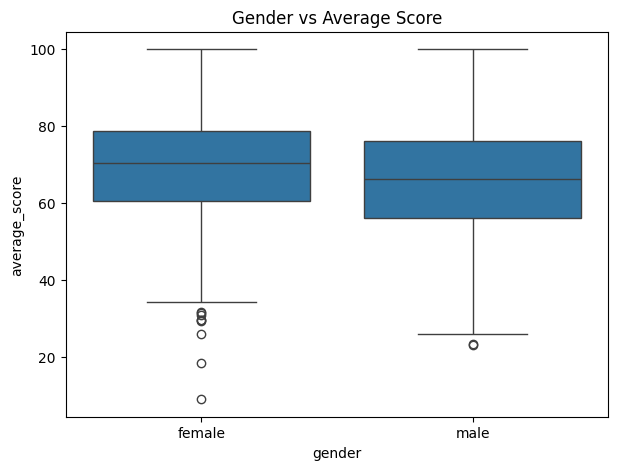

In [27]:
plt.figure(figsize=(7,5))
sns.boxplot(x='gender', y='average_score', data=df)
plt.title("Gender vs Average Score")
plt.show()

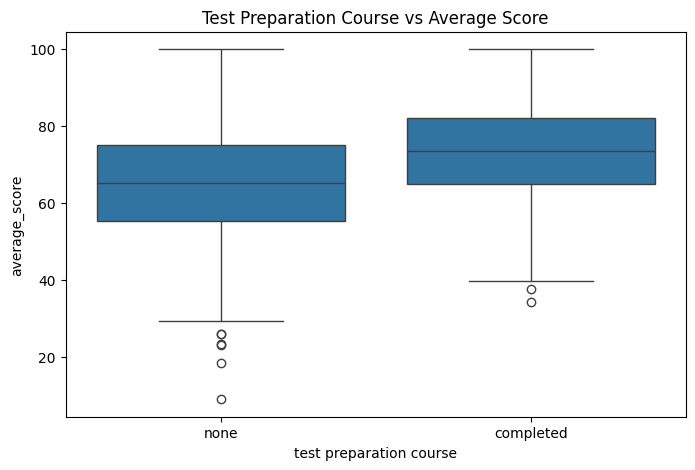

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='test preparation course', y='average_score', data=df)
plt.title("Test Preparation Course vs Average Score")
plt.show()

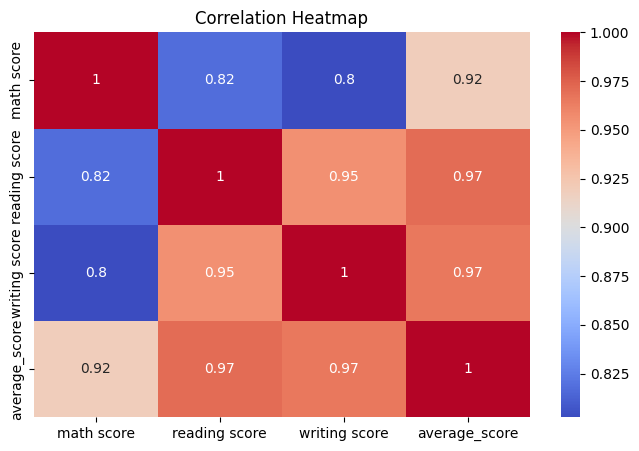

In [29]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['math score', 'reading score', 'writing score', 'average_score']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [30]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,Result
0,0,1,1,1,1,72,72,74,72.666667,1
1,0,2,4,1,0,69,90,88,82.333333,1
2,0,1,3,1,1,90,95,93,92.666667,1
3,1,0,0,0,1,47,57,44,49.333333,0
4,1,2,4,1,1,76,78,75,76.333333,1


In [31]:
X = df.drop(['math score', 'reading score', 'writing score', 'average_score', 'Result'], axis=1)
y = df['Result']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   gender  race/ethnicity  parental level of education  lunch  \
0       0               1                            1      1   
1       0               2                            4      1   
2       0               1                            3      1   
3       1               0                            0      0   
4       1               2                            4      1   

   test preparation course  
0                        1  
1                        0  
2                        1  
3                        1  
4                        1  

Target:
0    1
1    1
2    1
3    0
4    1
Name: Result, dtype: int64


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (800, 5)
Testing data shape: (200, 5)


In [42]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [43]:
y_pred = model.predict(X_test)

print("Predictions:", y_pred[:10])

Predictions: [1 1 1 1 1 1 1 1 1 1]


In [44]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.855


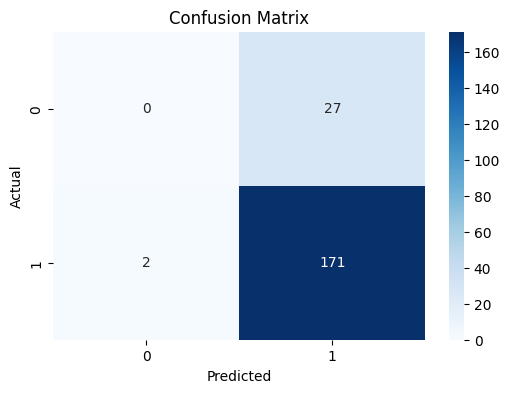

In [45]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.86      0.99      0.92       173

    accuracy                           0.85       200
   macro avg       0.43      0.49      0.46       200
weighted avg       0.75      0.85      0.80       200



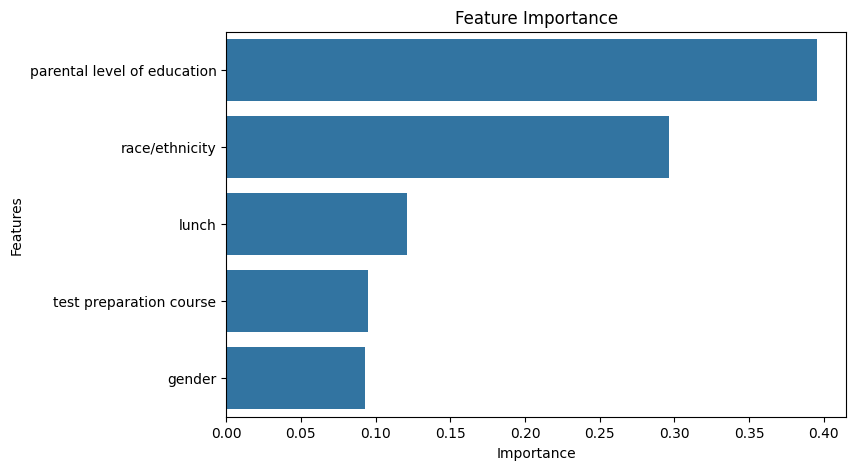

In [47]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [48]:
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [49]:
y_pred = model.predict(X_test)

print("Predictions:", y_pred[:10])

Predictions: [1 1 1 1 1 1 1 0 1 1]


In [50]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.775


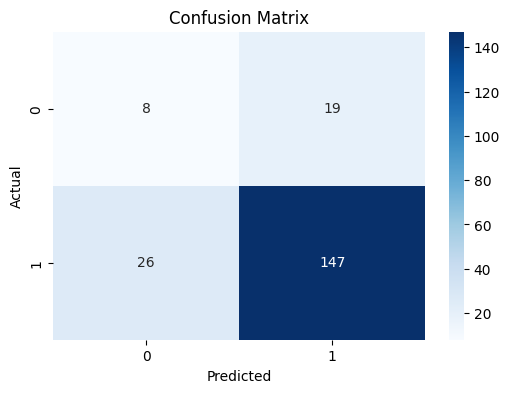

In [51]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.24      0.30      0.26        27
           1       0.89      0.85      0.87       173

    accuracy                           0.78       200
   macro avg       0.56      0.57      0.56       200
weighted avg       0.80      0.78      0.79       200



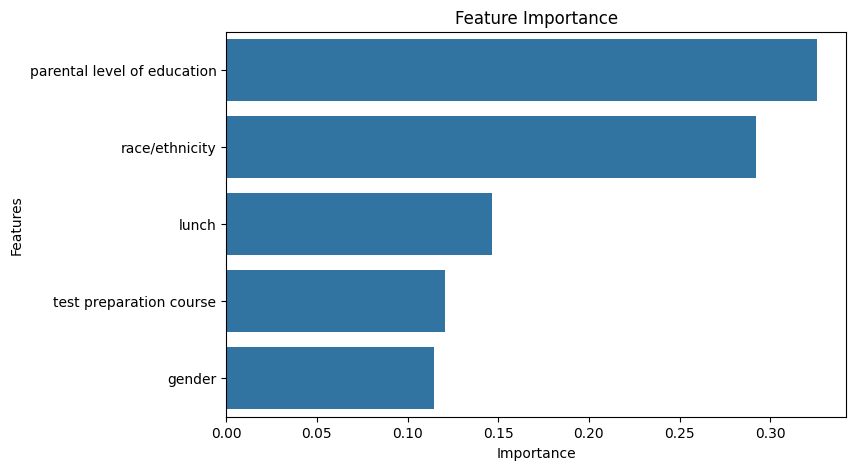

In [53]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [ ]:
## Conclusion

In this project, the student performance dataset was analyzed to build a machine learning prediction model.

The dataset was first cleaned by checking and handling missing values. Then, a new feature called `average_score` was created using math, reading, and writing scores. Based on this average score, students were classified as pass or fail.

Several visualizations were created to understand how student background factors affect performance. A Random Forest Classifier was used to train the model and predict the student result.

Initially, the dataset was imbalanced because most students belonged to the pass category. To improve prediction quality, the model was retrained using `class_weight='balanced'`.

The final model achieved good accuracy and showed that features like parental level of education, race/ethnicity, and lunch type had a noticeable influence on prediction.

This project successfully demonstrates:
- data cleaning
- exploratory data analysis
- data visualization
- machine learning model training
- prediction and evaluation